# SMS Spam Classification using KNN

**Assignment type:** NLP / Text Analysis  
**Learning type:** Binary Classification  
**Algorithm:** K-Nearest Neighbors (KNN), implemented from scratch  
**Dataset:** SMS Spam Collection (Text Classification), Kaggle  
**Target class:** `1 = spam`, `0 = ham / not spam`

### Students
- Student 1: `Arsenii S, ID: 2319`
- Student 2: `Kristina S, ID: 7553`
- Student 3: `Maxim G, ID: 7344`

## Dataset and learning problem

This project uses the **SMS Spam Collection** dataset from Kaggle for supervised binary text classification. Each row contains an SMS message and a label indicating whether it is spam (`1`) or ham (`0`). The goal is to classify unseen SMS messages. Because KNN operates on numeric vectors, raw text is converted into TF-IDF features implemented from scratch.

### AI / chatbot usage

AI assistance was used for project planning, code review, debugging, checking the assignment requirements, and explaining the implementation.

Example prompt used:
> Help us implement and review an NLP spam-classification project using KNN from scratch, including TF-IDF feature engineering, 5-Fold Cross Validation, grid search, imbalance handling, explainability, and F1 evaluation. Do not use a ready-made ML classifier.

Purpose:
- structure the notebook according to the assignment;
- review/debug code;
- explain the ML flow and outputs.

Dataset URL:  
https://www.kaggle.com/datasets/thedevastator/sms-spam-collection-a-more-diverse-dataset?resource=download


## Dataset preparation and fixed train/test split

The Kaggle download contains one labeled CSV file. Before creating the project subsets, exact duplicate SMS texts are removed (ignoring only leading/trailing whitespace) so that the same message cannot appear in both training and test data.

A **fixed stratified split** with random seed `42` is then created once outside this notebook:
- `train.csv` — 85% of the deduplicated data;
- `test.csv` — 15% of the deduplicated data.

The notebook **does not split the test set again**. Model selection is performed only on `train.csv` using **5-Fold Cross Validation**. The test labels are not used for model selection.

The optional `prepare_data.py` file reproduces these fixed CSV files from the Kaggle source.


In [1]:
import re
import math
from collections import Counter
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## Part 1 — Introduction and dataset loading

**Learning problem:** classify an SMS message as spam (`1`) or not spam (`0`).

The notebook loads the fixed `train.csv` and `test.csv` files and shows the first 5 rows of each set.


In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

required_columns = {"sms", "label"}
assert required_columns.issubset(train_df.columns)
assert required_columns.issubset(test_df.columns)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nFirst 5 train rows:")
display(train_df.head())

print("\nFirst 5 test rows:")
display(test_df.head())


Train shape: (4386, 2)
Test shape: (774, 2)

First 5 train rows:


,sms,label
0,In e msg jus now. U said thanks for gift.\n,0
1,Yes there were many sweets\n,0
2,Hey babe! I saw you came online for a second a...,0
3,Oooh bed ridden ey? What are YOU thinking of?\n,0
4,Thanx...\n,0



First 5 test rows:


,sms,label
0,"Sir, I am waiting for your mail.\n",0
1,S:-)if we have one good partnership going we w...,0
2,Lmao!nice 1\n,0
3,RECPT 1/3. You have ordered a Ringtone. Your o...,1
4,How much r ü willing to pay?\n,0


In [3]:
summary = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(train_df), len(test_df)],
    "ham_count": [int((train_df["label"] == 0).sum()), int((test_df["label"] == 0).sum())],
    "spam_count": [int((train_df["label"] == 1).sum()), int((test_df["label"] == 1).sum())],
})
summary["spam_rate"] = summary["spam_count"] / summary["rows"]
display(summary)

train_keys = set(train_df["sms"].astype(str).str.strip())
test_keys = set(test_df["sms"].astype(str).str.strip())
print("Train/test SMS overlap:", len(train_keys.intersection(test_keys)))
assert train_keys.isdisjoint(test_keys), "Data leakage: duplicate SMS appears in train and test"


,split,rows,ham_count,spam_count,spam_rate
0,train,4386,3840,546,0.124487
1,test,774,678,96,0.124031


Train/test SMS overlap: 0


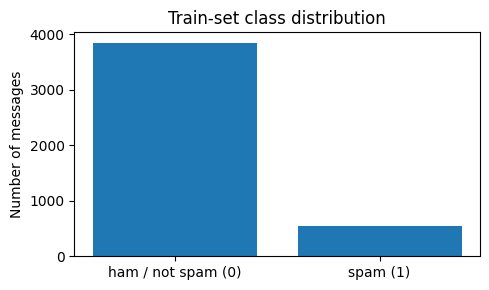

In [4]:
label_counts = train_df["label"].value_counts().sort_index()
plt.figure(figsize=(5, 3))
plt.bar(["ham / not spam (0)", "spam (1)"], [label_counts.get(0, 0), label_counts.get(1, 0)])
plt.title("Train-set class distribution")
plt.ylabel("Number of messages")
plt.tight_layout()
plt.show()


## Quality Metric

This is binary classification with one central/important class: **spam (`1`)**. Therefore the main metric is **F1-score for the spam class**.

- **Precision** = TP / (TP + FP)
- **Recall** = TP / (TP + FN)
- **F1** = 2 × Precision × Recall / (Precision + Recall)

Accuracy and the confusion matrix are shown as additional information, but **F1 for spam** is used to compare configurations.


## Part 2 — Feature Engineering

KNN cannot compare raw text directly, so every message is converted into a numeric vector.

### Preprocessing
1. convert text to lowercase;
2. keep letters, digits and apostrophes;
3. tokenize into words;
4. optionally add adjacent **bigrams** as an extension.

### TF-IDF from scratch
- **TF (Term Frequency):** frequency of a feature inside one message;
- **IDF (Inverse Document Frequency):** gives more weight to features that occur in fewer training messages;
- vectors are L2-normalized before cosine similarity is used.

The vectorizer is always fitted **only on the training part** of the current experiment/fold to prevent leakage.

For Bonus 6A we experiment with multiple Feature Engineering settings: `max_features`, `min_df`, and unigram vs unigram+bigrams.


In [5]:
def tokenize(text):
    return re.findall(r"[a-z0-9']+", str(text).lower())


def text_features(text, ngram_mode="unigram"):
    words = tokenize(text)
    if ngram_mode == "unigram":
        return words
    if ngram_mode == "unigram_bigram":
        bigrams = [f"{words[i]}__{words[i+1]}" for i in range(len(words) - 1)]
        return words + bigrams
    raise ValueError("ngram_mode must be 'unigram' or 'unigram_bigram'")


class TfidfVectorizerScratch:
    """TF-IDF vectorizer implemented from scratch."""

    def __init__(self, max_features=600, min_df=2, ngram_mode="unigram"):
        self.max_features = int(max_features)
        self.min_df = int(min_df)
        self.ngram_mode = ngram_mode
        self.vocabulary_ = {}
        self.idf_ = None

    def fit(self, texts):
        document_frequency = Counter()
        for text in texts:
            document_frequency.update(set(text_features(text, self.ngram_mode)))

        features = [
            feature for feature, count in document_frequency.items()
            if count >= self.min_df
        ]
        features = sorted(
            features,
            key=lambda f: (-document_frequency[f], f)
        )[:self.max_features]

        self.vocabulary_ = {feature: i for i, feature in enumerate(features)}
        n_documents = len(texts)
        self.idf_ = np.array([
            math.log((1 + n_documents) / (1 + document_frequency[feature])) + 1
            for feature in features
        ], dtype=np.float32)
        return self

    def transform(self, texts):
        X = np.zeros((len(texts), len(self.vocabulary_)), dtype=np.float32)

        for row, text in enumerate(texts):
            counts = Counter(text_features(text, self.ngram_mode))
            total = sum(count for feature, count in counts.items() if feature in self.vocabulary_)
            total = max(total, 1)

            for feature, count in counts.items():
                col = self.vocabulary_.get(feature)
                if col is not None:
                    tf = count / total
                    X[row, col] = tf * self.idf_[col]

        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return X / norms

    def fit_transform(self, texts):
        return self.fit(texts).transform(texts)


### Feature Engineering examples — 3 train and 3 test messages

A baseline TF-IDF setting is fitted on the training set only. For readability, only the strongest non-zero features are displayed.


In [6]:
baseline_vectorizer = TfidfVectorizerScratch(max_features=600, min_df=2, ngram_mode="unigram")
baseline_vectorizer.fit(train_df["sms"].tolist())


def top_features_for_text(text, fitted_vectorizer, top_n=8):
    vector = fitted_vectorizer.transform([text])[0]
    reverse_vocab = {idx: word for word, idx in fitted_vectorizer.vocabulary_.items()}
    nonzero = np.flatnonzero(vector)
    return sorted(
        [(reverse_vocab[i], float(vector[i])) for i in nonzero],
        key=lambda item: item[1], reverse=True
    )[:top_n]


for split_name, frame in [("TRAIN", train_df.head(3)), ("TEST", test_df.head(3))]:
    print(f"\n===== {split_name} EXAMPLES =====")
    for _, row in frame.iterrows():
        print("\nOriginal SMS:", row["sms"])
        print("Label:", row["label"])
        print("Tokens:", tokenize(row["sms"])[:20])
        print("Top TF-IDF features:", top_features_for_text(row["sms"], baseline_vectorizer))



===== TRAIN EXAMPLES =====

Original SMS: In e msg jus now. U said thanks for gift.

Label: 0
Tokens: ['in', 'e', 'msg', 'jus', 'now', 'u', 'said', 'thanks', 'for', 'gift']
Top TF-IDF features: [('gift', 0.42776450514793396), ('jus', 0.402893602848053), ('said', 0.3531216084957123), ('thanks', 0.35203319787979126), ('e', 0.3429603576660156), ('msg', 0.33331894874572754), ('now', 0.23228052258491516), ('for', 0.21365876495838165)]

Original SMS: Yes there were many sweets

Label: 0
Tokens: ['yes', 'there', 'were', 'many', 'sweets']
Top TF-IDF features: [('many', 0.5465912818908691), ('were', 0.5396531820297241), ('yes', 0.47890251874923706), ('there', 0.42504677176475525)]

Original SMS: Hey babe! I saw you came online for a second and then you disappeared, what happened ?

Label: 0
Tokens: ['hey', 'babe', 'i', 'saw', 'you', 'came', 'online', 'for', 'a', 'second', 'and', 'then', 'you', 'disappeared', 'what', 'happened']
Top TF-IDF features: [('online', 0.4074104130268097), ('saw', 0.39

## Part 3 — KNN implementation from scratch

For each new SMS, KNN:
1. compares its normalized TF-IDF vector to all training vectors;
2. uses cosine similarity (`distance = 1 - cosine_similarity`);
3. takes the `k` nearest examples;
4. predicts from their labels.

### KNN hyperparameters
- `k` — number of nearest neighbors;
- `voting`:
  - `uniform`: every neighbor has equal influence;
  - `weighted`: closer neighbors receive larger weight.

The classifier uses no ready-made scikit-learn model.


In [7]:
class KNNScratch:
    """KNN classifier implemented from scratch for L2-normalized vectors."""

    def __init__(self, k=5, voting="uniform"):
        if k < 1:
            raise ValueError("k must be >= 1")
        if voting not in {"uniform", "weighted"}:
            raise ValueError("voting must be 'uniform' or 'weighted'")
        self.k = int(k)
        self.voting = voting
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=np.float32)
        self.y_train = np.asarray(y, dtype=int)
        return self

    @staticmethod
    def _vote(neighbor_sim, neighbor_labels, voting):
        if voting == "uniform":
            spam_score = neighbor_labels.mean(axis=1)
        else:
            distances = 1.0 - neighbor_sim
            weights = 1.0 / np.maximum(distances, 1e-6)
            spam_score = (weights * neighbor_labels).sum(axis=1) / weights.sum(axis=1)
        return (spam_score >= 0.5).astype(int)

    def predict(self, X, batch_size=256):
        X = np.asarray(X, dtype=np.float32)
        predictions = []

        for start in range(0, len(X), batch_size):
            batch = X[start:start + batch_size]
            similarities = batch @ self.X_train.T
            k = min(self.k, self.X_train.shape[0])
            neighbor_idx = np.argpartition(-similarities, kth=k - 1, axis=1)[:, :k]
            neighbor_sim = np.take_along_axis(similarities, neighbor_idx, axis=1)
            neighbor_labels = self.y_train[neighbor_idx]
            predictions.extend(self._vote(neighbor_sim, neighbor_labels, self.voting).tolist())

        return np.array(predictions, dtype=int)


def train_knn(X, y, k, voting):
    return KNNScratch(k=k, voting=voting).fit(X, y)


def predict_knn(model, X):
    return model.predict(X)


## Evaluation functions implemented from scratch


In [8]:
def classification_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return {
        "accuracy": accuracy,
        "precision_spam": precision,
        "recall_spam": recall,
        "f1_spam": f1,
        "TP": tp, "TN": tn, "FP": fp, "FN": fn
    }


## Bonus 6A — Feature Engineering + Hyperparameter Grid Search with 5-Fold Cross Validation

All model selection is performed on the **training set only**.

We test the Cartesian product of:

**Feature Engineering settings**
- `max_features ∈ {400, 600}`
- `min_df ∈ {1, 2}`
- `ngram_mode ∈ {unigram, unigram_bigram}`

**KNN hyperparameters**
- `k ∈ {5, 9}`
- `voting ∈ {uniform, weighted}`

This produces **32 permutations**. Each permutation is evaluated across **5 stratified folds**, and the mean spam F1 is used for selection.

To reduce runtime without changing the experiment, each fold's cosine-similarity matrix is calculated once for a Feature Engineering configuration and reused for the KNN `k`/`voting` permutations.


In [9]:
def stratified_kfold_indices(y, n_splits=5, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    per_class_folds = {}

    for label in np.unique(y):
        idx = np.where(y == label)[0]
        rng.shuffle(idx)
        per_class_folds[label] = np.array_split(idx, n_splits)

    folds = []
    all_idx = np.arange(len(y))
    for fold_i in range(n_splits):
        val_idx = np.concatenate([per_class_folds[label][fold_i] for label in sorted(per_class_folds)])
        train_idx = np.setdiff1d(all_idx, val_idx, assume_unique=False)
        folds.append((train_idx, val_idx))
    return folds


def predict_from_similarity(similarities, y_reference, k, voting):
    k = min(int(k), similarities.shape[1])
    neighbor_idx = np.argpartition(-similarities, kth=k - 1, axis=1)[:, :k]
    neighbor_sim = np.take_along_axis(similarities, neighbor_idx, axis=1)
    neighbor_labels = np.asarray(y_reference)[neighbor_idx]
    return KNNScratch._vote(neighbor_sim, neighbor_labels, voting)


In [10]:
y_train_all = train_df["label"].to_numpy(dtype=int)
folds = stratified_kfold_indices(y_train_all, n_splits=5, seed=RANDOM_SEED)

feature_grid = {
    "max_features": [400, 600],
    "min_df": [1, 2],
    "ngram_mode": ["unigram", "unigram_bigram"],
}
model_grid = {
    "k": [5, 9],
    "voting": ["uniform", "weighted"],
}

rows = []

for max_features, min_df, ngram_mode in product(
    feature_grid["max_features"],
    feature_grid["min_df"],
    feature_grid["ngram_mode"],
):
    # One score list per model hyperparameter pair for this FE configuration.
    scores = {(k, voting): [] for k, voting in product(model_grid["k"], model_grid["voting"])}

    for train_idx, val_idx in folds:
        fold_train_texts = train_df.iloc[train_idx]["sms"].tolist()
        fold_val_texts = train_df.iloc[val_idx]["sms"].tolist()
        fold_y_train = y_train_all[train_idx]
        fold_y_val = y_train_all[val_idx]

        vec = TfidfVectorizerScratch(
            max_features=max_features,
            min_df=min_df,
            ngram_mode=ngram_mode,
        )
        X_fold_train = vec.fit_transform(fold_train_texts)
        X_fold_val = vec.transform(fold_val_texts)

        similarities = X_fold_val @ X_fold_train.T

        for k, voting in scores:
            pred = predict_from_similarity(similarities, fold_y_train, k=k, voting=voting)
            scores[(k, voting)].append(classification_metrics(fold_y_val, pred)["f1_spam"])

    for (k, voting), fold_scores in scores.items():
        rows.append({
            "max_features": max_features,
            "min_df": min_df,
            "ngram_mode": ngram_mode,
            "k": k,
            "voting": voting,
            "fold_1_f1": fold_scores[0],
            "fold_2_f1": fold_scores[1],
            "fold_3_f1": fold_scores[2],
            "fold_4_f1": fold_scores[3],
            "fold_5_f1": fold_scores[4],
            "mean_f1": float(np.mean(fold_scores)),
        })

grid_results_df = pd.DataFrame(rows).sort_values(
    ["mean_f1", "max_features"], ascending=[False, True]
).reset_index(drop=True)

display(grid_results_df)


,max_features,min_df,ngram_mode,k,voting,fold_1_f1,fold_2_f1,fold_3_f1,fold_4_f1,fold_5_f1,mean_f1
0,600,1,unigram,5,weighted,0.907317,0.880000,0.897561,0.890000,0.923077,0.899591
1,600,2,unigram,5,weighted,0.907317,0.880000,0.897561,0.890000,0.923077,0.899591
2,600,1,unigram,9,weighted,0.910891,0.875622,0.896552,0.895522,0.912621,0.898242
3,600,2,unigram,9,weighted,0.910891,0.875622,0.896552,0.895522,0.912621,0.898242
4,600,1,unigram_bigram,9,weighted,0.890000,0.895522,0.907317,0.886700,0.884422,0.892792
5,600,2,unigram_bigram,9,weighted,0.890000,0.895522,0.907317,0.886700,0.884422,0.892792
6,600,1,unigram_bigram,5,weighted,0.894472,0.861538,0.890000,0.900990,0.912621,0.891924
7,600,2,unigram_bigram,5,weighted,0.894472,0.861538,0.890000,0.900990,0.912621,0.891924
8,400,1,unigram_bigram,9,weighted,0.886700,0.871287,0.902913,0.902913,0.881188,0.889000
9,400,2,unigram_bigram,9,weighted,0.886700,0.871287,0.902913,0.902913,0.881188,0.889000


In [11]:
best_row = grid_results_df.iloc[0]
BEST_MAX_FEATURES = int(best_row["max_features"])
BEST_MIN_DF = int(best_row["min_df"])
BEST_NGRAM_MODE = str(best_row["ngram_mode"])
BEST_K = int(best_row["k"])
BEST_VOTING = str(best_row["voting"])
BEST_CV_F1 = float(best_row["mean_f1"])

print("Best Feature Engineering + KNN permutation")
print("max_features:", BEST_MAX_FEATURES)
print("min_df:", BEST_MIN_DF)
print("ngram_mode:", BEST_NGRAM_MODE)
print("k:", BEST_K)
print("voting:", BEST_VOTING)
print("Mean 5-Fold spam F1:", round(BEST_CV_F1, 4))


Best Feature Engineering + KNN permutation
max_features: 600
min_df: 1
ngram_mode: unigram
k: 5
voting: weighted
Mean 5-Fold spam F1: 0.8996


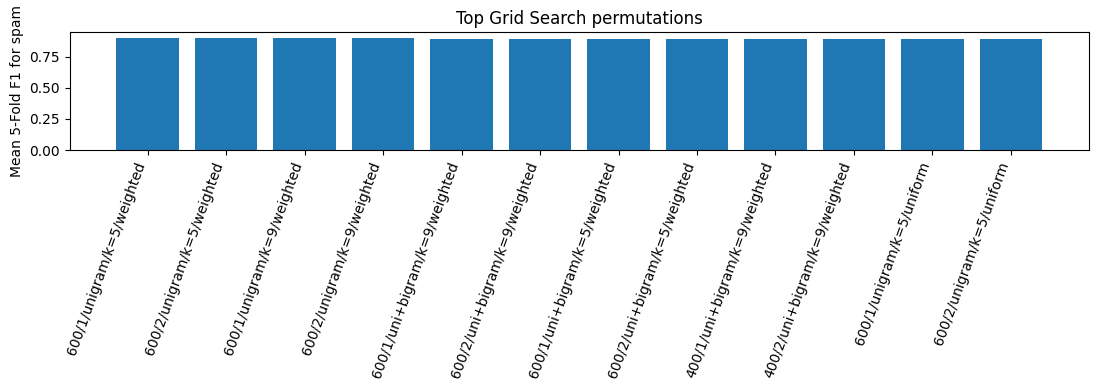

In [12]:
plot_df = grid_results_df.head(12).copy()
plot_df["setting"] = (
    plot_df["max_features"].astype(str) + "/" +
    plot_df["min_df"].astype(str) + "/" +
    plot_df["ngram_mode"].str.replace("unigram_", "uni+", regex=False) +
    "/k=" + plot_df["k"].astype(str) + "/" + plot_df["voting"]
)
plt.figure(figsize=(11, 4))
plt.bar(plot_df["setting"], plot_df["mean_f1"])
plt.xticks(rotation=70, ha="right")
plt.ylabel("Mean 5-Fold F1 for spam")
plt.title("Top Grid Search permutations")
plt.tight_layout()
plt.show()


## Bonus 6B — Imbalanced-data adaptation with random oversampling

The training set contains many more ham messages than spam messages. Random oversampling duplicates minority-class **training examples only** until the two classes are balanced.

To evaluate this extension fairly, we again use the same **5-Fold Cross Validation** structure. Oversampling is applied only to the 4 training folds; the validation fold is never oversampled.

The best Feature Engineering and KNN settings from Bonus 6A are used for both baseline and oversampled runs. We choose oversampling for final training only if it improves the mean spam F1.


In [13]:
def random_oversample_minority(X, y, seed=42):
    rng = np.random.default_rng(seed)
    X = np.asarray(X)
    y = np.asarray(y)

    counts = {label: np.where(y == label)[0] for label in np.unique(y)}
    majority_label = max(counts, key=lambda label: len(counts[label]))
    minority_label = min(counts, key=lambda label: len(counts[label]))
    majority_idx = counts[majority_label]
    minority_idx = counts[minority_label]

    n_to_add = len(majority_idx) - len(minority_idx)
    sampled_idx = rng.choice(minority_idx, size=n_to_add, replace=True)

    X_bal = np.concatenate([X, X[sampled_idx]], axis=0)
    y_bal = np.concatenate([y, y[sampled_idx]], axis=0)
    order = rng.permutation(len(y_bal))
    return X_bal[order], y_bal[order]


In [14]:
baseline_fold_scores = []
oversampled_fold_scores = []

for fold_number, (train_idx, val_idx) in enumerate(folds, start=1):
    fold_train_texts = train_df.iloc[train_idx]["sms"].tolist()
    fold_val_texts = train_df.iloc[val_idx]["sms"].tolist()
    fold_y_train = y_train_all[train_idx]
    fold_y_val = y_train_all[val_idx]

    vec = TfidfVectorizerScratch(
        max_features=BEST_MAX_FEATURES,
        min_df=BEST_MIN_DF,
        ngram_mode=BEST_NGRAM_MODE,
    )
    X_fold_train = vec.fit_transform(fold_train_texts)
    X_fold_val = vec.transform(fold_val_texts)

    baseline_model = train_knn(X_fold_train, fold_y_train, BEST_K, BEST_VOTING)
    baseline_pred = baseline_model.predict(X_fold_val)
    baseline_fold_scores.append(classification_metrics(fold_y_val, baseline_pred)["f1_spam"])

    X_bal, y_bal = random_oversample_minority(X_fold_train, fold_y_train, seed=RANDOM_SEED + fold_number)
    oversampled_model = train_knn(X_bal, y_bal, BEST_K, BEST_VOTING)
    oversampled_pred = oversampled_model.predict(X_fold_val)
    oversampled_fold_scores.append(classification_metrics(fold_y_val, oversampled_pred)["f1_spam"])

imbalance_cv_df = pd.DataFrame({
    "method": ["Original training folds", "Random oversampling"],
    "fold_1_f1": [baseline_fold_scores[0], oversampled_fold_scores[0]],
    "fold_2_f1": [baseline_fold_scores[1], oversampled_fold_scores[1]],
    "fold_3_f1": [baseline_fold_scores[2], oversampled_fold_scores[2]],
    "fold_4_f1": [baseline_fold_scores[3], oversampled_fold_scores[3]],
    "fold_5_f1": [baseline_fold_scores[4], oversampled_fold_scores[4]],
    "mean_f1": [np.mean(baseline_fold_scores), np.mean(oversampled_fold_scores)],
})
display(imbalance_cv_df)

USE_OVERSAMPLING = float(imbalance_cv_df.loc[1, "mean_f1"]) > float(imbalance_cv_df.loc[0, "mean_f1"])
print("Use oversampling in final model:", USE_OVERSAMPLING)


,method,fold_1_f1,fold_2_f1,fold_3_f1,fold_4_f1,fold_5_f1,mean_f1
0,Original training folds,0.907317,0.880000,0.897561,0.890000,0.923077,0.899591
1,Random oversampling,0.852174,0.834711,0.809717,0.842975,0.832653,0.834446


Use oversampling in final model: False


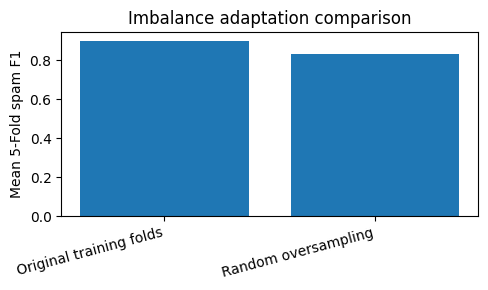

In [15]:
plt.figure(figsize=(5, 3))
plt.bar(imbalance_cv_df["method"], imbalance_cv_df["mean_f1"])
plt.ylabel("Mean 5-Fold spam F1")
plt.title("Imbalance adaptation comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## Part 4 — Final training on the complete trainset

After the cross-validation experiments, the successful configuration is used to retrain on **all rows of `train.csv`**.

The TF-IDF vectorizer is fitted again from scratch on the complete training set using the selected Feature Engineering settings. If Bonus 6B showed a higher mean F1 for oversampling, oversampling is applied only to this final training representation.

Below, 3 training examples are shown through the selected Feature Engineering configuration before final fitting.


In [16]:
final_vectorizer = TfidfVectorizerScratch(
    max_features=BEST_MAX_FEATURES,
    min_df=BEST_MIN_DF,
    ngram_mode=BEST_NGRAM_MODE,
)
X_final_train = final_vectorizer.fit_transform(train_df["sms"].tolist())
y_final_train = train_df["label"].to_numpy(dtype=int)

print("Selected FE settings:", {
    "max_features": BEST_MAX_FEATURES,
    "min_df": BEST_MIN_DF,
    "ngram_mode": BEST_NGRAM_MODE,
})
print("Final training matrix:", X_final_train.shape)

for _, row in train_df.head(3).iterrows():
    print("\nSMS:", row["sms"])
    print("Selected TF-IDF features:", top_features_for_text(row["sms"], final_vectorizer))

if USE_OVERSAMPLING:
    X_model_train, y_model_train = random_oversample_minority(X_final_train, y_final_train, seed=RANDOM_SEED)
else:
    X_model_train, y_model_train = X_final_train, y_final_train

final_model = train_knn(X_model_train, y_model_train, BEST_K, BEST_VOTING)
print("\nFinal KNN settings:", {"k": BEST_K, "voting": BEST_VOTING})
print("Final model training rows:", len(y_model_train))


Selected FE settings: {'max_features': 600, 'min_df': 1, 'ngram_mode': 'unigram'}
Final training matrix: (4386, 600)

SMS: In e msg jus now. U said thanks for gift.

Selected TF-IDF features: [('gift', 0.42776450514793396), ('jus', 0.402893602848053), ('said', 0.3531216084957123), ('thanks', 0.35203319787979126), ('e', 0.3429603576660156), ('msg', 0.33331894874572754), ('now', 0.23228052258491516), ('for', 0.21365876495838165)]

SMS: Yes there were many sweets

Selected TF-IDF features: [('many', 0.5465912818908691), ('were', 0.5396531820297241), ('yes', 0.47890251874923706), ('there', 0.42504677176475525)]

SMS: Hey babe! I saw you came online for a second and then you disappeared, what happened ?

Selected TF-IDF features: [('online', 0.4074104130268097), ('saw', 0.3973066210746765), ('came', 0.39138123393058777), ('babe', 0.3279784917831421), ('hey', 0.3004370629787445), ('you', 0.28154727816581726), ('then', 0.255094975233078), ('what', 0.2523176670074463)]

Final KNN settings: {'k

## Part 5 — Prediction and final test-set evaluation

The test set is transformed with the **already fitted final vectorizer**; no vocabulary or IDF information is learned from test data.

We show 3 test messages through Feature Engineering, then the first 5 model predictions, followed by F1, Precision, Recall, Accuracy and the confusion matrix. Test performance is reported as the final evaluation and is not used to change the selected configuration.


In [17]:
X_test = final_vectorizer.transform(test_df["sms"].tolist())
y_test = test_df["label"].to_numpy(dtype=int)

for _, row in test_df.head(3).iterrows():
    print("\nTEST SMS:", row["sms"])
    print("Selected TF-IDF features:", top_features_for_text(row["sms"], final_vectorizer))

test_predictions = final_model.predict(X_test)
test_metrics = classification_metrics(y_test, test_predictions)

print("\nFinal test metrics:")
display(pd.DataFrame([test_metrics]))



TEST SMS: Sir, I am waiting for your mail.

Selected TF-IDF features: [('mail', 0.5081630945205688), ('sir', 0.49512821435928345), ('waiting', 0.4536009728908539), ('am', 0.3484708368778229), ('your', 0.2662334442138672), ('for', 0.25949108600616455), ('i', 0.17668253183364868)]

TEST SMS: S:-)if we have one good partnership going we will take lead:)

Selected TF-IDF features: [('we', 0.532630980014801), ('s', 0.3661286532878876), ('take', 0.33044949173927307), ('one', 0.3152357339859009), ('going', 0.31151217222213745), ('good', 0.2910306453704834), ('will', 0.26340681314468384), ('if', 0.2621239423751831)]

TEST SMS: Lmao!nice 1

Selected TF-IDF features: [('nice', 0.7726296186447144), ('1', 0.6348569989204407)]



Final test metrics:


,accuracy,precision_spam,recall_spam,f1_spam,TP,TN,FP,FN
0,0.976744,0.9875,0.822917,0.897727,79,677,1,17


In [18]:
first_five = test_df.head(5).copy()
first_five["prediction"] = test_predictions[:5]
first_five["actual_name"] = first_five["label"].map({0: "ham", 1: "spam"})
first_five["predicted_name"] = first_five["prediction"].map({0: "ham", 1: "spam"})
print("First 5 test predictions:")
display(first_five[["sms", "label", "prediction", "actual_name", "predicted_name"]])


First 5 test predictions:


,sms,label,prediction,actual_name,predicted_name
0,"Sir, I am waiting for your mail.\n",0,0,ham,ham
1,S:-)if we have one good partnership going we w...,0,0,ham,ham
2,Lmao!nice 1\n,0,0,ham,ham
3,RECPT 1/3. You have ordered a Ringtone. Your o...,1,1,spam,spam
4,How much r ü willing to pay?\n,0,0,ham,ham


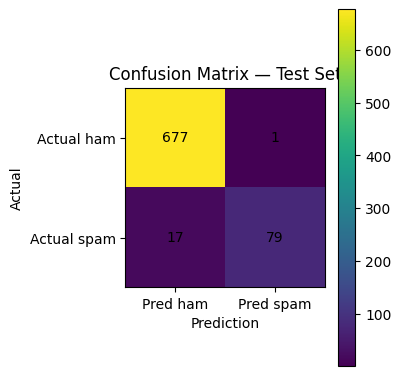

In [19]:
cm = np.array([
    [test_metrics["TN"], test_metrics["FP"]],
    [test_metrics["FN"], test_metrics["TP"]]
])

plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Confusion Matrix — Test Set")
plt.xticks([0, 1], ["Pred ham", "Pred spam"])
plt.yticks([0, 1], ["Actual ham", "Actual spam"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()


## Bonus 6C — Explainability

KNN is naturally instance-based: a prediction can be explained by inspecting the nearest training examples that voted for it.

For a selected test message we display:
- true and predicted class;
- nearest training messages;
- cosine similarity and distance;
- neighbor labels;
- the vote weight used by weighted KNN.

This directly exposes the training information that influenced the prediction.


In [20]:
def explain_knn_prediction(test_index, test_df, reference_df, fitted_vectorizer, model, top_k=None):
    if top_k is None:
        top_k = model.k

    text = test_df.iloc[test_index]["sms"]
    true_label = int(test_df.iloc[test_index]["label"])
    x = fitted_vectorizer.transform([text])
    similarities = (x @ model.X_train.T)[0]
    k = min(top_k, len(similarities))
    neighbor_idx = np.argsort(-similarities)[:k]
    neighbor_labels = model.y_train[neighbor_idx]
    neighbor_sim = similarities[neighbor_idx]
    distances = 1.0 - neighbor_sim

    if model.voting == "weighted":
        vote_weight = 1.0 / np.maximum(distances, 1e-6)
    else:
        vote_weight = np.ones_like(distances)

    prediction = int(model.predict(x)[0])

    # When oversampling is disabled, model rows map directly to train_df rows.
    # If oversampling is enabled, duplicated feature rows do not have a unique original row,
    # so we find the closest original training text for display.
    if len(model.y_train) == len(reference_df):
        sms_values = reference_df.iloc[neighbor_idx]["sms"].values
    else:
        original_X = fitted_vectorizer.transform(reference_df["sms"].tolist())
        sms_values = []
        for ni in neighbor_idx:
            closest_original = int(np.argmax(model.X_train[ni] @ original_X.T))
            sms_values.append(reference_df.iloc[closest_original]["sms"])

    explanation = pd.DataFrame({
        "neighbor_rank": np.arange(1, k + 1),
        "cosine_similarity": neighbor_sim,
        "cosine_distance": distances,
        "vote_weight": vote_weight,
        "label": neighbor_labels,
        "label_name": ["spam" if x == 1 else "ham" for x in neighbor_labels],
        "sms": sms_values,
    })

    print("Test SMS:", text)
    print("True class:", "spam" if true_label else "ham")
    print("Predicted class:", "spam" if prediction else "ham")
    display(explanation)
    return explanation


In [21]:
# Choose the first spam example in the test set for a clear explanation example.
spam_test_indices = np.where(test_df["label"].to_numpy() == 1)[0]
EXPLAIN_INDEX = int(spam_test_indices[0])

explanation_df = explain_knn_prediction(
    test_index=EXPLAIN_INDEX,
    test_df=test_df,
    reference_df=train_df,
    fitted_vectorizer=final_vectorizer,
    model=final_model,
)


Test SMS: RECPT 1/3. You have ordered a Ringtone. Your order is being processed...

True class: spam
Predicted class: spam


,neighbor_rank,cosine_similarity,cosine_distance,vote_weight,label,label_name,sms
0,1,0.360510,0.639490,1.563745,1,spam,"Thanks for your ringtone order, reference numb..."
1,2,0.356168,0.643832,1.553201,1,spam,"Thanks for your ringtone order, ref number R83..."
2,3,0.356168,0.643832,1.553201,1,spam,"Thanks for your ringtone order, ref number K71..."
3,4,0.353345,0.646655,1.546419,1,spam,"New Tones This week include: 1)McFly-All Ab..,..."
4,5,0.351833,0.648167,1.542813,0,ham,Where's mummy's boy ? Is he being good or bad ...


### Explainability interpretation

The table above makes the KNN decision transparent: the prediction is driven directly by the labels and similarities of the nearest training examples. In weighted voting, neighbors with smaller cosine distance receive larger vote weight.


## Conclusions

This notebook demonstrates the complete supervised-learning process required for the project:

1. load fixed train and test datasets and verify no overlap;
2. use F1 for the central spam class;
3. implement TF-IDF Feature Engineering from scratch and show train/test examples;
4. implement KNN, training and prediction from scratch;
5. run a full Cartesian Grid Search over Feature Engineering and KNN hyperparameters;
6. wrap every grid permutation in stratified 5-Fold Cross Validation;
7. evaluate imbalance handling with oversampling inside Cross Validation;
8. retrain the selected configuration on the complete trainset;
9. evaluate once on the fixed test set and show the first 5 predictions;
10. explain a prediction through its nearest neighbors.


In [22]:
print("FINAL SUMMARY")
print("Best CV configuration:", {
    "max_features": BEST_MAX_FEATURES,
    "min_df": BEST_MIN_DF,
    "ngram_mode": BEST_NGRAM_MODE,
    "k": BEST_K,
    "voting": BEST_VOTING,
    "mean_cv_f1_spam": round(BEST_CV_F1, 4),
    "oversampling_selected": USE_OVERSAMPLING,
})
print("Final test metrics:", {
    key: round(value, 4) if isinstance(value, float) else value
    for key, value in test_metrics.items()
})


FINAL SUMMARY
Best CV configuration: {'max_features': 600, 'min_df': 1, 'ngram_mode': 'unigram', 'k': 5, 'voting': 'weighted', 'mean_cv_f1_spam': 0.8996, 'oversampling_selected': False}
Final test metrics: {'accuracy': 0.9767, 'precision_spam': 0.9875, 'recall_spam': 0.8229, 'f1_spam': 0.8977, 'TP': 79, 'TN': 677, 'FP': 1, 'FN': 17}


## 5-minute presentation checklist

1. Introduce all three students, the problem, dataset, target class and why F1 for spam is used.
2. Show 2–3 TF-IDF examples and explain TF, IDF, normalization and leakage prevention.
3. Explain KNN from scratch: cosine similarity, `k`, uniform/weighted voting, `fit` and `predict`.
4. Show the Bonus 6A DataFrame: Cartesian product of Feature Engineering + KNN hyperparameters, 5-Fold CV, mean F1 and best permutation.
5. Show Bonus 6B oversampling comparison and explain why it was or was not selected.
6. Show final first 5 test predictions, metrics and confusion matrix.
7. Show Bonus 6C nearest-neighbor explanation and explain how neighbors influence the decision.

The code and saved outputs should be visible in the repository without requiring the reviewer to run the notebook.
